<a href="https://colab.research.google.com/github/duddet01/Population-modeling/blob/main/BioAssign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
from scipy.integrate import odeint

Tmat=np.array([[0.4,3],[0.32,0.7]])

Eigenvalue=np.linalg.eigvals(Tmat)
print(Eigenvalue)
print("Population size ratio for two successive generations at equilibrium:",np.max(Eigenvalue))
eigval,eigvec = np.linalg.eig(Tmat)

print(eigvec[:,1])

sum_sad=np.sum(eigvec[:,1])


Juvenile_ratio=eigvec[:,1][0]/sum_sad

print("Juvenile ratio is:",Juvenile_ratio)

[-0.44121138  1.54121138]
Population size ratio for two successive generations at equilibrium: 1.5412113800799505
[-0.9346582  -0.35554753]
Juvenile ratio is: 0.724425711382567


In [ ]:
#species1
n1=[70,70,30,30]
r1=1
k1=200
alpha12=0.8


#species2
n2=[175,75,120,100]
r2=0.5
k2=300
alpha21=2


solution1=[]
solution2=[]
solution3=[]
solution4=[]

for i in range (0,4):
   initialpop=[n1[i],n2[i]]                            #species 1 and 2 initial pop


   t=np.linspace(0,150,num=10000)   #timestamps
   params=[r1,r2,alpha12,alpha21,k1,k2]



   def dNdt(variables,t,params):
     #unpacking locally
     #species 1,2 population levels
      n1=variables[0]
      n2=variables[1]

      r1=params[0]
      r2=params[1]
      alpha12=params[2]
      alpha21=params[3]
      k1=params[4]
      k2=params[5]

      dn1dt= r1*n1*(k1-n1-n2*alpha12)/k1
      dn2dt= r2*n2*(k2-n2-n1*alpha21)/k2

      return(dn1dt , dn2dt)

   Solution=odeint(dNdt,initialpop,t,args=(params,))

   print("solution:"+ str(i+1), Solution,sep="\n")

   if i==0:
    solution1=Solution
   elif i==1:
    solution2=Solution
   elif i==2:
    solution3=Solution
   elif i==3:
    solution4=Solution




solution:1
[[7.00000000e+01 1.75000000e+02]
 [6.99477885e+01 1.74934752e+02]
 [6.98961602e+01 1.74870266e+02]
 ...
 [8.81246638e-08 3.00000000e+02]
 [8.78567657e-08 3.00000000e+02]
 [8.75896796e-08 3.00000000e+02]]
solution:2
[[7.00000000e+01 7.50000000e+01]
 [7.03671977e+01 7.51587207e+01]
 [7.07337047e+01 7.53160981e+01]
 ...
 [2.00000000e+02 1.07646987e-08]
 [2.00000000e+02 1.07585789e-08]
 [2.00000000e+02 1.07524651e-08]]
solution:3
[[3.00000000e+01 1.20000000e+02]
 [3.01664654e+01 1.20359534e+02]
 [3.03328225e+01 1.20718057e+02]
 ...
 [2.81305971e-09 3.00000000e+02]
 [2.80508944e-09 3.00000000e+02]
 [2.79713694e-09 3.00000000e+02]]
solution:4
[[3.00000000e+01 1.00000000e+02]
 [3.02026586e+01 1.00349701e+02]
 [3.04055864e+01 1.00698724e+02]
 ...
 [1.99999999e+02 7.26058231e-07]
 [1.99999999e+02 7.24246241e-07]
 [1.99999999e+02 7.22438460e-07]]


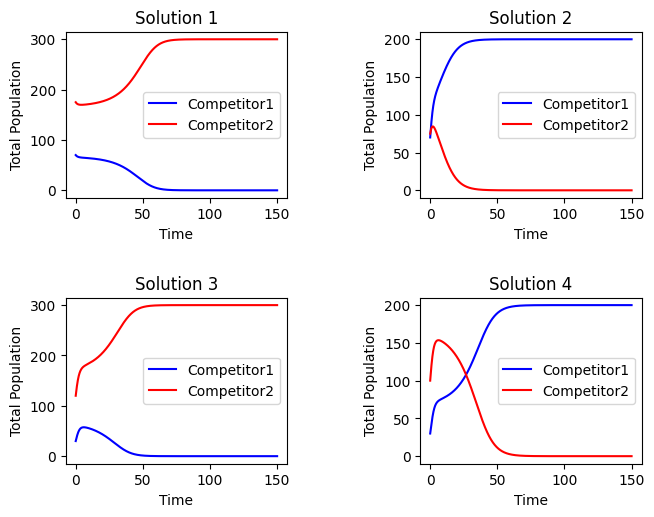

In [ ]:


fig, ax = plt.subplots(2,2)
plt.subplots_adjust(left=0.1,bottom=0.1,right=1,top=1,wspace=0.6,hspace=0.6)

ax[0,0].plot(t,solution1[:,0],color="blue",label="Competitor1")
ax[0,0].plot(t,solution1[:,1],color="red",label="Competitor2")
ax[0,0].title.set_text('Solution 1')
ax[0,0].set_ylabel("Total Population")
ax[0,0].set_xlabel("Time")
ax[0,0].legend(fontsize="10")


ax[0,1].plot(t,solution2[:,0],color="blue",label="Competitor1")
ax[0,1].plot(t,solution2[:,1],color="red",label="Competitor2")
ax[0,1].title.set_text('Solution 2')
ax[0,1].set_ylabel("Total Population")
ax[0,1].set_xlabel("Time")
ax[0,1].legend(fontsize="10")


ax[1,0].plot(t,solution3[:,0],color="blue",label="Competitor1")
ax[1,0].plot(t,solution3[:,1],color="red",label="Competitor2")
ax[1,0].title.set_text('Solution 3')
ax[1,0].set_ylabel("Total Population")
ax[1,0].set_xlabel("Time")
ax[1,0].legend(fontsize="10")


ax[1,1].plot(t,solution4[:,0],color="blue",label="Competitor1")
ax[1,1].plot(t,solution4[:,1],color="red",label="Competitor2")
ax[1,1].title.set_text('Solution 4')
ax[1,1].set_ylabel("Total Population")
ax[1,1].set_xlabel("Time")
ax[1,1].legend(fontsize="10")


Intersection point is: [ 66.66666667 166.66666667]


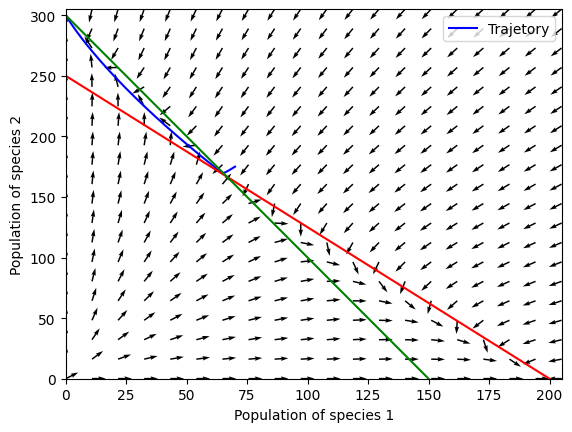

In [ ]:
#plot1
plt.plot(solution1[:,0],solution1[:,1],color="blue",label='Trajetory')
plt.legend()
plt.ylabel("Population of species 2")
plt.xlabel("Population of species 1")

N1_space=np.linspace(0,np.max([k1,k2/alpha21])+5,100)
N2_space=np.linspace(0,np.max([k2,k1/alpha12])+5,100)

N1_max=np.max(N1_space)
N2_max=np.max(N2_space)

equi1=k1/alpha12-N1_space/alpha12     #plots of isocline with respext to N1 axis
equi2=k2-alpha21*N1_space

plt.plot(N1_space,equi1,color="red")
plt.plot(N1_space,equi2,color="green")


plt.xlim(0,N1_max)
plt.ylim(0,N2_max)

x=np.linspace(0.1,N1_max,20)
y=np.linspace(0.1,N2_max,20)
xx,yy=np.meshgrid(x,y)
NN1,NN2=dNdt((xx,yy),0,params) #Derivate each point of the phase diagram to get vector field
norm=np.sqrt(NN1**2+NN2**2)
NN1=NN1/norm
NN2=NN2/norm

plt.quiver(xx,yy,NN1,NN2,cmap=plt.cm.gray)

a=np.array([[1,1/alpha21],[1/alpha12,1]])
b=np.array([k2/alpha21,k1/alpha12])
intersection_point=np.linalg.solve(a,b)

print("Intersection point is:", intersection_point)  #but the equilibrium is unstable so population go to max and 0


(0.0, 305.0)

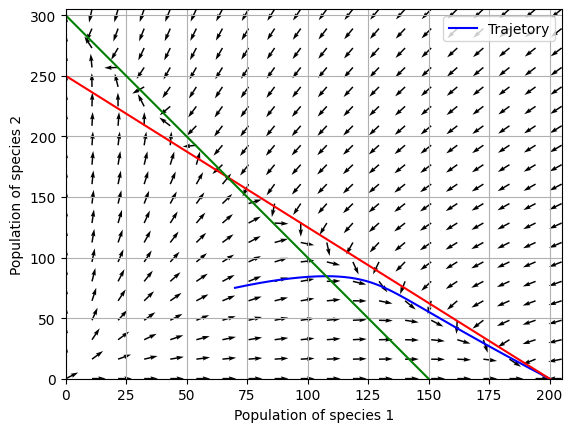

In [ ]:
#plot2
plt.plot(solution2[:,0],solution2[:,1],color="blue",label='Trajetory')
plt.legend()

plt.ylabel("Population of species 2")
plt.xlabel("Population of species 1")

N1_space=np.linspace(0,np.max([k1,k2/alpha21])+5,100)
N2_space=np.linspace(0,np.max([k2,k1/alpha12])+5,100)

N1_max=np.max(N1_space)
N2_max=np.max(N2_space)

equi1=k1/alpha12-N1_space/alpha12     #plots of isocline with respext to N1 axis
equi2=k2-alpha21*N1_space

plt.plot(N1_space,equi1,color="red")
plt.plot(N1_space,equi2,color="green")
plt.grid()

x=np.linspace(0.1,N1_max,20)
y=np.linspace(0.1,N2_max,20)
xx,yy=np.meshgrid(x,y)
NN1,NN2=dNdt((xx,yy),0,params) #Derivate each point of the phase diagram to get vector field
norm=np.sqrt(NN1**2+NN2**2)
NN1=NN1/norm
NN2=NN2/norm

plt.quiver(xx,yy,NN1,NN2,cmap=plt.cm.gray)


plt.xlim(0,N1_max)
plt.ylim(0,N2_max)

(0.0, 305.0)

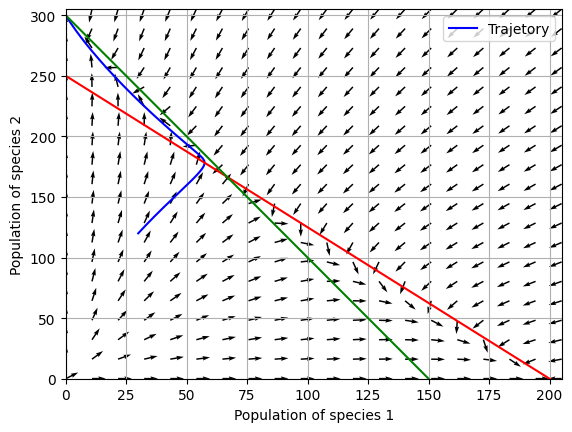

In [ ]:
#plot3
plt.plot(solution3[:,0],solution3[:,1],color="blue",label='Trajetory')
plt.legend()

plt.ylabel("Population of species 2")
plt.xlabel("Population of species 1")

N1_space=np.linspace(0,np.max([k1,k2/alpha21])+5,100)
N2_space=np.linspace(0,np.max([k2,k1/alpha12])+5,100)

N1_max=np.max(N1_space)
N2_max=np.max(N2_space)

equi1=k1/alpha12-N1_space/alpha12     #plots of isocline with respext to N1 axis
equi2=k2-alpha21*N1_space

plt.plot(N1_space,equi1,color="red")
plt.plot(N1_space,equi2,color="green")
plt.grid()

x=np.linspace(0.1,N1_max,20)
y=np.linspace(0.1,N2_max,20)
xx,yy=np.meshgrid(x,y)
NN1,NN2=dNdt((xx,yy),0,params) #Derivate each point of the phase diagram to get vector field
norm=np.sqrt(NN1**2+NN2**2)
NN1=NN1/norm
NN2=NN2/norm

plt.quiver(xx,yy,NN1,NN2,cmap=plt.cm.gray)


plt.xlim(0,N1_max)
plt.ylim(0,N2_max)

(0.0, 305.0)

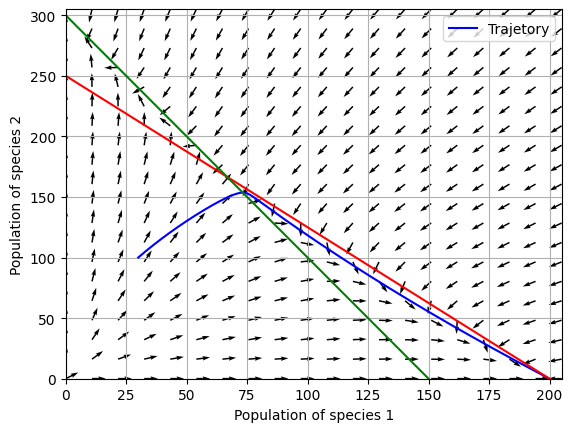

In [ ]:
#plot4
plt.plot(solution4[:,0],solution4[:,1],color="blue",label='Trajetory')
plt.legend()

plt.ylabel("Population of species 2")
plt.xlabel("Population of species 1")

N1_space=np.linspace(0,np.max([k1,k2/alpha21])+5,100)
N2_space=np.linspace(0,np.max([k2,k1/alpha12])+5,100)

N1_max=np.max(N1_space)
N2_max=np.max(N2_space)

equi1=k1/alpha12-N1_space/alpha12     #plots of isocline with respext to N1 axis
equi2=k2-alpha21*N1_space

plt.plot(N1_space,equi1,color="red")
plt.plot(N1_space,equi2,color="green")
plt.grid()

x=np.linspace(0.1,N1_max,20)
y=np.linspace(0.1,N2_max,20)
xx,yy=np.meshgrid(x,y)
NN1,NN2=dNdt((xx,yy),0,params) #Derivate each point of the phase diagram to get vector field
norm=np.sqrt(NN1**2+NN2**2)
NN1=NN1/norm
NN2=NN2/norm

plt.quiver(xx,yy,NN1,NN2,cmap=plt.cm.gray)


plt.xlim(0,N1_max)
plt.ylim(0,N2_max)

In [ ]:
#Q3(a)
#cohort life table - to find net R0 value
Age=np.array([0,1,2,3,4,5,6,7,8,9,10,11])
Survivors=[250,239,210,156,129,109,76,43,32,19,9,0]
Proportion_survivors=[]
for i in range(0,12):
  ratio=Survivors[i]/250
  Proportion_survivors.append(ratio)
Avg_eggs_per_capita=np.array([0,0,0,0.551,0.412,0.251,0.99,0.95,0.71,0.49,0.135,0])
Eggs_producedby_surviving_indiv=Proportion_survivors*Avg_eggs_per_capita

print("Proportion surviving to day x:",Proportion_survivors,sep="\n")
print("Avg no of seeds per capita:",Avg_eggs_per_capita,sep="\n")

print("Eggs produced per indiv per surviving proprotion" , Eggs_producedby_surviving_indiv,sep="\n")

R0_value=np.sum(Eggs_producedby_surviving_indiv)     #R0=net per capita reproductive rate.
print("R0 value for this population is:",R0_value)

if R0_value < 1:
  print("It is a declining population")
elif R0_value >=1:
  print("It is an increasing population")


Proportion surviving to day x:
[1.0, 0.956, 0.84, 0.624, 0.516, 0.436, 0.304, 0.172, 0.128, 0.076, 0.036, 0.0]
Avg no of seeds per capita:
[0.    0.    0.    0.551 0.412 0.251 0.99  0.95  0.71  0.49  0.135 0.   ]
Eggs produced per indiv per surviving proprotion
[0.       0.       0.       0.343824 0.212592 0.109436 0.30096  0.1634
 0.09088  0.03724  0.00486  0.      ]
R0 value for this population is: 1.263192
It is an increasing population


In [ ]:
#Q3(b)
#cohort life table - to find net R0 value
Age=np.array([0,1,2,3,4,5,6,7,8,9,10,11,12,13])
Survivors=[250,239,210,156,129,109,76,43,32,19,9,9,9,0]
Proportion_survivors=[]
for i in range(0,14):
  ratio=Survivors[i]/250
  Proportion_survivors.append(ratio)
Avg_eggs_per_capita=np.array([0,0,0,0,0.412,0.251,0.99,0.95,0.71,0.49,0.27,0.27,0.27,0])
Eggs_producedby_surviving_indiv=Proportion_survivors*Avg_eggs_per_capita

print("Proportion surviving to day x:",Proportion_survivors,sep="\n")
print("Avg no of seeds per capita:",Avg_eggs_per_capita,sep="\n")

print("Eggs produced per indiv per surviving proprotion" , Eggs_producedby_surviving_indiv,sep="\n")

R0_value=np.sum(Eggs_producedby_surviving_indiv)     #R0=net per capita reproductive rate.
print("R0 value for this population is:",R0_value)

if R0_value < 1:
  print("It is a declining population")
elif R0_value >=1:
  print("It is an increasing population")


Proportion surviving to day x:
[1.0, 0.956, 0.84, 0.624, 0.516, 0.436, 0.304, 0.172, 0.128, 0.076, 0.036, 0.036, 0.036, 0.0]
Avg no of seeds per capita:
[0.    0.    0.    0.    0.412 0.251 0.99  0.95  0.71  0.49  0.27  0.27
 0.27  0.   ]
Eggs produced per indiv per surviving proprotion
[0.       0.       0.       0.       0.212592 0.109436 0.30096  0.1634
 0.09088  0.03724  0.00972  0.00972  0.00972  0.      ]
R0 value for this population is: 0.9436679999999997
It is a declining population


In [ ]:
#Q4 Lotka volterra Predator Prey Model

r1=1.05
C=0.1
d2=0.6
g=0.45

#N is the prey population (Sangai Deer) and P is the predator population (Cheetah)
#Initial pop=(N,P)
Initial_pop=[30,10]

params=(r1,C,d2,g)
t=np.linspace(0,50,num=1000)   #no of timestamps

def dNdt (variables,t,params):

    N=variables[0]
    P=variables[1]

    r1=params[0]
    C=params[1]
    d2=params[2]
    g=params[3]


    dNdt=r1*N-C*N*P
    dPdt=-d2*P + g*C*N*P

    return(dNdt,dPdt)

Solution=odeint(dNdt,Initial_pop,t,args=(params,))
Solution_integer=Solution.astype('int32')
print(Solution.astype('int32'))
print(Solution)

flag= False

for i in range(0,1000):
  if np.all(Solution_integer[i]==[18,15]):
    print("month number is:",i)
    flag=True
    break
if flag==True:
  print("Ideal population size is reached")
else:
  print("Ideal population size is not reached")




[[30 10]
 [30 10]
 [30 10]
 ...
 [28  7]
 [28  7]
 [28  8]]
[[30.         10.        ]
 [30.04653899 10.38316584]
 [30.03434922 10.78143516]
 ...
 [28.06784136  7.63048975]
 [28.45545319  7.89145323]
 [28.80963204  8.16816766]]
Ideal population size is not reached


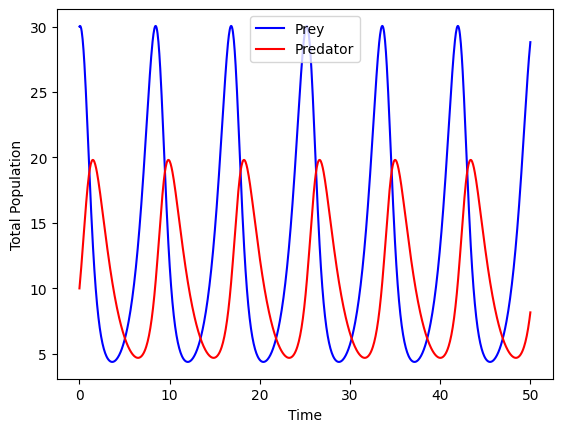

In [ ]:
plt.plot(t,Solution[:,0],color="blue",label="Prey")
plt.plot(t,Solution[:,1],color="red",label="Predator")
plt.ylabel("Total Population")
plt.xlabel("Time")
plt.legend()

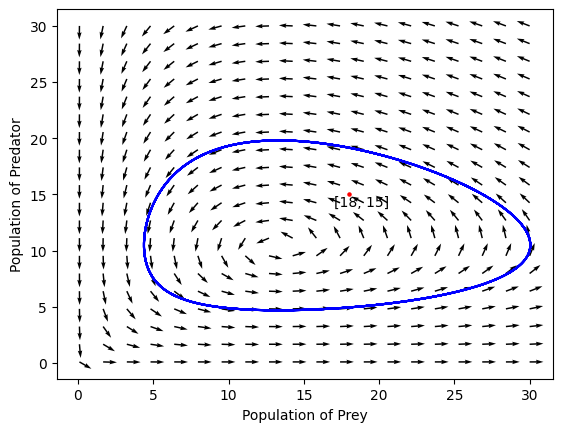

In [ ]:
plt.plot(Solution[:,0],Solution[:,1],color="blue")


plt.ylabel("Population of Predator")
plt.xlabel("Population of Prey")

plt.scatter(18,15,color="red",s=5)

plt.annotate([18,15],xy=(17,14))

x=np.linspace(0.1,30,20)
y=np.linspace(0.1,30,20)
xx,yy=np.meshgrid(x,y)
NN1,NN2=dNdt((xx,yy),0,params) #Derivate each point of the phase diagram to get vector field
norm=np.sqrt(NN1**2+NN2**2)
NN1=NN1/norm
NN2=NN2/norm
plt.quiver(xx,yy,NN1,NN2,cmap=plt.cm.gray)